In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
load_data_from_npz = np.load("FIP35-tICA.npz")
tics_of_trajs = np.concatenate([load_data_from_npz['GTT0'], load_data_from_npz['GTT1']], axis=0)
print(tics_of_trajs.shape)
traj_lens = load_data_from_npz['traj_lens']
# 58 trajs for 1.1 ms, 3 tics
# (1 frame = 1 ns)

(1137344, 3)


In [4]:
# tics_of_trajs has to be 3D
#basis_list = amuset_tica.Basis.find([tics_of_trajs], [2,2,2], sigma=-1, mix=False)
#print(basis_list)
basis_list = np.array([[[-0.5402968893832484, 2], [1.6977050721019225, 2]], [[0.03775098344108225, 2], [-0.11639949878185235, 2]], [[0.011024319620013722, 2], [-0.031054131813476105, 2]]])

ttica = amuset_tica.AmusetTICA()
svd_v, _ = ttica.build(basis_list, [tics_of_trajs])
print(svd_v.shape)

(27, 1137344)


In [7]:
ITSs = []
lag_times = list(range(1, 151))
Ks, Es, Vs = [], [], []

for i in lag_times:
    ttica.covariance(svd_v, traj_lens, lag_time=i)
    Ks.append(ttica._K)
    evK, vrK = np.linalg.eig(ttica._K)
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", i, 'frames')
    ITSs.append(ttica.timescales_[:6])
    print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(4):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

Time = 1 frames
[884.58308078  31.18157955  22.20279683  13.02450777   7.13419349
   5.18576591]
Time = 2 frames
[1453.42749156   51.43970778   35.97308572   19.95167031   11.93371811
    8.4749837 ]
Time = 3 frames
[1942.14445351   68.94568615   47.27918075   24.96018622   15.92520176
   11.13269846]
Time = 4 frames
[2363.70571177   84.00086706   57.2398541    28.81976575   19.53637468
   13.51650282]
Time = 5 frames
[2749.19533582   97.89078782   65.65186704   32.18208255   23.03071401
   15.73761244]
Time = 6 frames
[3099.03421009  110.09140721   73.64450037   34.97248946   26.26995203
   17.73512306]
Time = 7 frames
[3410.94196014  121.72594877   80.14614882   37.27301019   29.30701691
   19.63570642]
Time = 8 frames
[3707.64096837  132.84281883   86.27140292   39.29663863   31.90374624
   21.44324459]
Time = 9 frames
[3975.6487932   143.68810585   91.9257879    41.15629995   34.62986791
   23.02324702]
Time = 10 frames
[4228.85641574  153.13061801   96.79765158   42.91090846   37.

KeyboardInterrupt: 

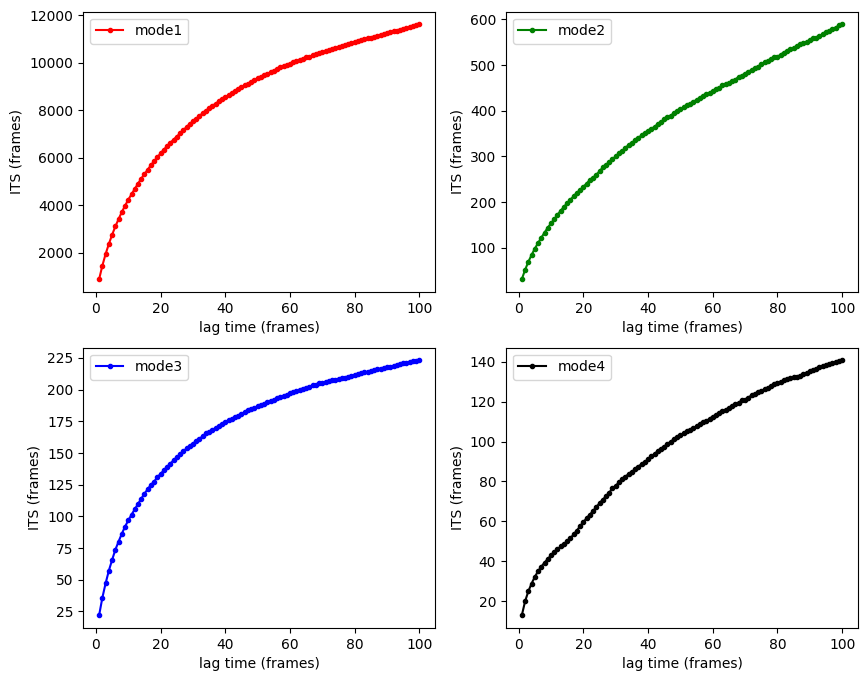

In [6]:
fig1, ax1 = plt.subplots(2, 2, figsize=(10, 8))
clr = ['r', 'g', 'b', 'k']
for i in range(4):
    ax1[i>>1][i&1].plot(lag_times, ITS[i], '.-', color=clr[i], label='mode'+str(i+1))
    ax1[i>>1][i&1].legend()
    ax1[i>>1][i&1].set_xlabel("lag time (frames)")
    ax1[i>>1][i&1].set_ylabel("ITS (frames)")
plt.show()

In [ ]:
Ks = np.array(Ks)
print(Ks.shape)
np.save("FIP35-Ks.npy", Ks)
# every 1 ns, 1 Koopman matrix

In [ ]:
ITSs = []
lag_times = list(range(100, 301, 10))
Ks, Es, Vs = [], [], []

for i in lag_times:
    ttica.covariance(svd_v, traj_lens, lag_time=i)
    Ks.append(ttica._K)
    evK, vrK = np.linalg.eig(ttica._K)
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", i, 'frames')
    ITSs.append(ttica.timescales_[:6])
    print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(4):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")